In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [54]:
train_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/training.csv')
test_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/test.csv')
validation_csv = pd.read_csv('../../data/ppi_affinity_dataset/raw/validation.csv')

In [55]:
data_csv = {'train_csv':train_csv,
            'test_csv':test_csv,
            'validation_csv':validation_csv}

In [14]:
def resample_uniform(df, feature, bins=10, n_per_bin=None):
    # Make bins
    df["strata"] = pd.qcut(df[feature], q=bins, duplicates="drop")
    
    # Count per bin to decide how much to keep
    counts = df["strata"].value_counts()
    if n_per_bin is None:
        n_per_bin = counts.min()  # keep as many as the *smallest* bin
    
    # Sample equal amounts per bin
    df_out = (
        df.groupby("strata", group_keys=False)
          .apply(lambda x: x.sample(n=min(len(x), n_per_bin), random_state=42))
    )

    return df_out.drop(columns=["strata"])

In [56]:
[x.split('-')[0] for x in list(data_csv['train_csv']['Sequence'])]

['IVEGSDAEIGMSPWQVMLFRKSPQELLCGASLISDRWVLTAAHCLLYPPWDKNFTENDLLVRIGKHSRTRYERNIEKISMLEKIYIHPRYNWRENLDRDIALMKLKKPVAFSDYIHPVCLPDRETAASLLQAGYKGRVTGWGNLKETWTANVGKGQPSVLQVVNLPIVERPVCKDSTRIRITDNMFCAGYKPDEGKRGDACEGDSGGPFVMKSPFNNRWYQMGIVSWGEGCDRDGKYGFYTHVFRLKKWIQKVIDQFGE',
 'IVEGSDAEIGMSPWQVMLFRKSPQELLCGASLISDRWVLTAAHCLLYPPWDKNFTENDLLVRIGKHSRTRYERNIEKISMLEKIYIHPRYNWRENLDRDIALMKLKKPVAFSDYIHPVCLPDRETAASLLQAGYKGRVTGWGNLKETWTANVGKGQPSVLQVVNLPIVERPVCKDSTRIRITDNMFCAGYKPDEGKRGDACEGDSGGPFVMKSPFNNRWYQMGIVSWGEGCDRDGKYGFYTHVFRLKKWIQKVIDQFGE',
 'IVCHTTATSPISAVTCPPGENLCYRKMWCDAFCSSRGKVVELGCAATCPSKKPYEEVTCCSTDKCNPHPKQRPG',
 'GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYWDGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDGKDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQRTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGTFQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRWEP',
 'MEDLIDGIIFAANYLGSTQLLSDKTPSKNVRMMQAQEAVSRIKMAQKLAKSRKKAPEGESQPMTEVDLFILTQRIKVLNADTQETMMDHPLRTISYIADIGNIVVLMARR

In [57]:
new_df = {}
for idx in data_csv.keys():
    seq_prot = [x.split('-')[0] for x in list(data_csv[idx]['Sequence'])]
    seq_pept = [x.split('-')[1] for x in list(data_csv[idx]['Sequence'])]
    energies = data_csv[idx]['delta_G']
    new_df[idx] =pd.DataFrame({'Energy':energies,
                                 'Prot_Seq':seq_prot,
                                 'Pept_Seq':seq_pept})
new_df['train_csv'][['Energy']] = new_df['train_csv'][['Energy']] * -1
new_df['test_csv'][['Energy']] = new_df['test_csv'][['Energy']] * -1
new_df['validation_csv'][['Energy']] = new_df['validation_csv'][['Energy']] * -1
scaler = MinMaxScaler(feature_range=(-1,1))
new_df['train_csv']['Energy']= scaler.fit_transform(new_df['train_csv'][['Energy']])
new_df['validation_csv']['Energy']= scaler.transform(new_df['validation_csv'][['Energy']])
new_df['test_csv']['Energy']= scaler.transform(new_df['test_csv'][['Energy']])

In [58]:
for idx in new_df.keys():
    new_df[idx].to_csv(f'../../data/ppi_affinity_dataset/cosine_sim_scaled/{str(idx.split('_')[0])}.csv')

In [3]:
t = pd.read_csv(f'../../data/ppi_affinity_dataset/cosine_sim_scaled/train.csv')

<Axes: xlabel='Energy', ylabel='Count'>

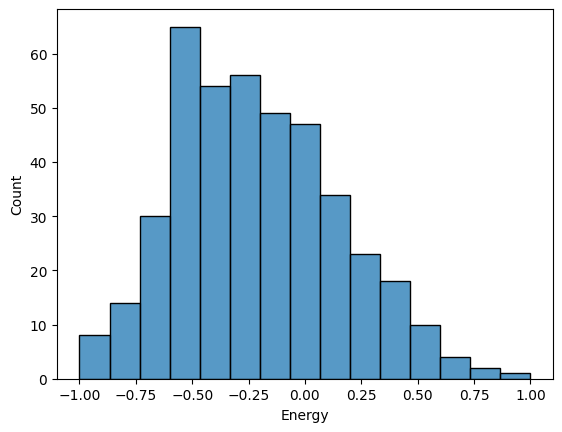

In [4]:
sns.histplot(t['Energy'])

In [22]:
t

,Unnamed: 0,Energy,Prot_Seq,Pept_Seq
0,0,0.736878,IVEGSDAEIGMSPWQVMLFRKSPQELLCGASLISDRWVLTAAHCLL...,GGQSHNDGDFEEIPEEYL
1,1,0.468425,IVEGSDAEIGMSPWQVMLFRKSPQELLCGASLISDRWVLTAAHCLL...,GGQSHNDGDFEEIPEEYL
2,2,-0.186276,IVCHTTATSPISAVTCPPGENLCYRKMWCDAFCSSRGKVVELGCAA...,KHWVYYTCCPDT
3,3,-0.677981,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,ILKEPVHGV
4,4,-0.315310,MEDLIDGIIFAANYLGSTQLLSDKTPSKNVRMMQAQEAVSRIKMAQ...,GYENPTYKFF
...,...,...,...,...
410,410,0.249298,GGGGSGGGGSGVLWDVPSPPETQKAELEEGVYRIKQQGIFGKTQVG...,GPLGSDLTVEKAADVTWEEEAEQTGVSHNLMITVDDDGTMRIKDDE...
411,411,0.050741,GAMGSSATQSKPTPVKPNYALKFTLAGHTKAVSSVKFSPNGEWLAS...,GCARSEPKILT
412,412,0.233661,GAMGSSATQSKPTPVKPNYALKFTLAGHTKAVSSVKFSPNGEWLAS...,GAARAEVYLR
413,413,-0.459101,GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMA...,LSSPVTKSF


<Axes: xlabel='Energy', ylabel='Density'>

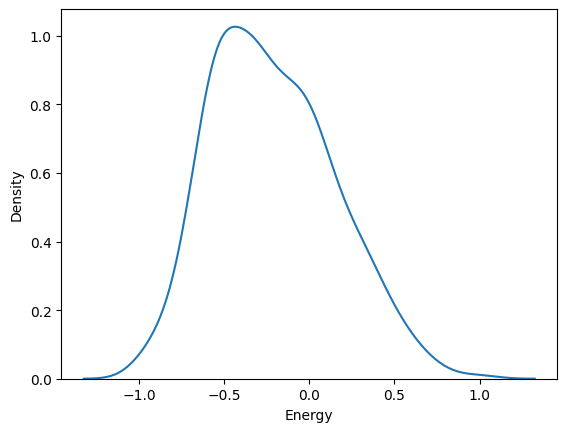

In [23]:
sns.kdeplot(t['Energy'])

In [57]:
col = "Energy"

# Make symmetric bins around zero
n_bins = 80
bins = np.linspace(-1, 1, n_bins + 1)
bin_idx = np.digitize(t[col], bins)

# For symmetry: pair left and right bins
keep_idx = []

for i in range(n_bins // 2):
    left_bin = i + 1
    right_bin = n_bins - i

    left_rows = t[bin_idx == left_bin]
    right_rows = t[bin_idx == right_bin]

    # keep equal amount from both sides
    k = min(len(left_rows), len(right_rows))

    if k > 0:
        keep_idx.append(left_rows.sample(k).index)
        keep_idx.append(right_rows.sample(k).index)

# If there is a center bin around zero, keep it completely
center_bin = n_bins // 2 + 1
center_rows = t[bin_idx == center_bin]
keep_idx.append(center_rows.index)

# final balanced dataframe
df_balanced = t.loc[np.concatenate(keep_idx)]

In [60]:
df_balanced

,Unnamed: 0,Energy,Prot_Seq,Pept_Seq
209,209,-1.000000,GPLGSDDVEWVVGKDKPTYDEIFYTLSPVNGKITGANAKKEMVKSK...,FNYESTGPFTAK
92,92,1.000000,CGVPAIQPVLSGLSRIVNGEEAVPGSWPWQVSLQDKTGFHFCGGSL...,IVNGEEAVPGSWPW
264,264,-0.804755,GSHMSKEPRDPDQLYSTLKSILQQVKSHQSAWPFMEPVKRTEAPGY...,STGGVKKPHRYKC
373,373,0.805568,IIGGSSSLPGSHPWLAAIYIGDSFCAGSLVHTCWVVSAAHCFSHSP...,VQLSPDLLATLPEPASPGRQACGRRHKKRTFLRPR
244,244,-0.743741,MEFKKVAKETAITLQSYLTYQAVRLISQQLSETNPGQAIWLGEFSK...,EIKFEFD
...,...,...,...,...
39,39,0.015943,GRVRWARALYDFEALEEDELGFRSGEVVEVLDSSNPSWWTGRLHNK...,APSIDRSTKPA
66,66,0.015943,MEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQPYP...,DLDLEMLAPYIPMDDDFQLR
152,152,0.021026,EVQLQQSGAELVRAGSSVKMSCKASGYTFTSYGINWVKQRPGQGLE...,SLGDNLTNHNLR
214,214,0.011086,GAMGKPFFTRNPSELKGKFIHTKLRKSSRGFGFTVVGGDEPDEFLQ...,RSSRTRRETQV


<Axes: xlabel='Energy', ylabel='Count'>

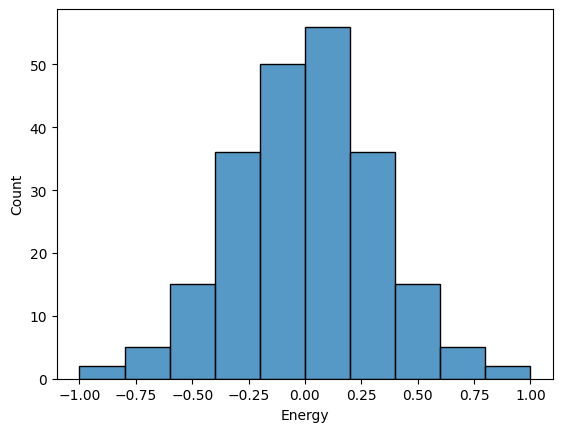

In [ ]:
sns.histplot(df_balanced['Energy'],bins=10)

<Axes: xlabel='Energy', ylabel='Density'>

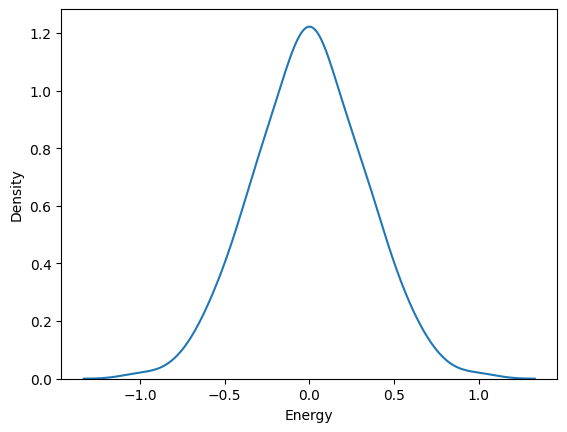

In [59]:
sns.kdeplot(df_balanced['Energy'])

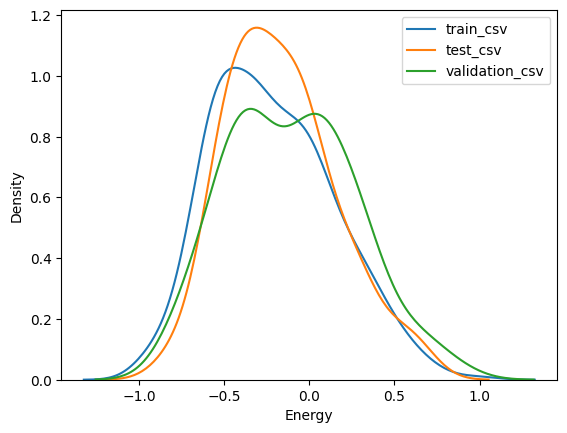

In [46]:
for idx in data_csv.keys():
    sns.kdeplot(new_df[idx]['Energy'], label=idx)
plt.legend()

<Axes: xlabel='delta_G', ylabel='Density'>

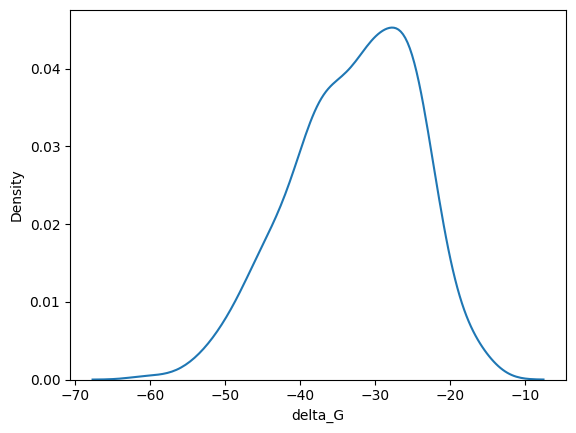

In [ ]:
sns.kdeplot(train_csv['delta_G'],)

<Axes: xlabel='delta_G', ylabel='Density'>

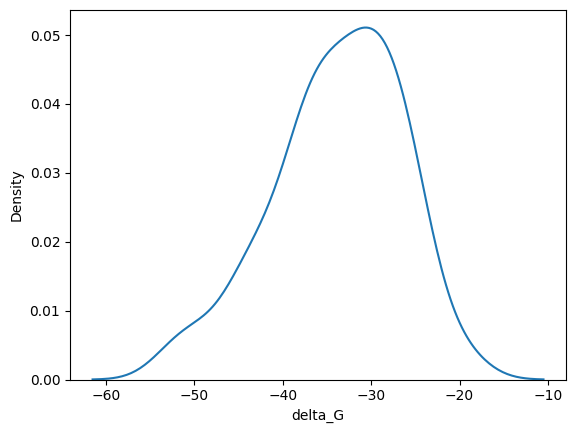

In [8]:
sns.kdeplot(test_csv['delta_G'])

<Axes: xlabel='delta_G', ylabel='Density'>

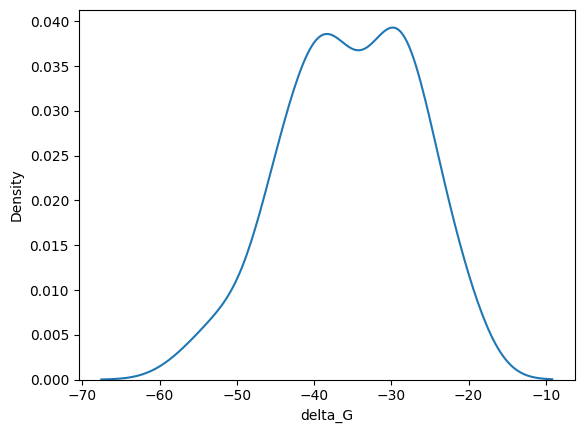

In [9]:
sns.kdeplot(validation_csv['delta_G'])